# Macroeconomic Indicators and Market Data Extraction

This section outlines the process of extracting critical macroeconomic indicators and financial market data required for analyzing the interplay between the US economy and its financial markets.

The data is sourced from two authoritative platforms:
1. **Yahoo Finance (`yfinance`)**: Used to extract daily historical closing prices for the S&P 500 index (`^GSPC`) as a proxy for the broader equity market, the US Dollar Index (`DX-Y.NYB`) to gauge currency strength, and the 10-Year (`^TNX`) and 2-Year (`^IRX`) US Treasury Yields to monitor interest rate environments and yield curve dynamics.
2. **Federal Reserve Economic Data (FRED)**: Accessed via `pandas_datareader` to obtain fundamental macroeconomic signals, specifically the Gross Domestic Product (GDP) and the Consumer Price Index (CPI), which indicate overall economic growth and inflation trends, respectively.

These specific indicators were selected to form a comprehensive view of the US economic health and market sentiment from January 2000 to the present date.


In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime

# Define the extraction period: January 1, 2000 to the current date
start_date = '2000-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

# ---------------------------------------------------------
# 1. Financial Market Data Extraction via Yahoo Finance
# ---------------------------------------------------------
# Define the trading tickers:
# ^GSPC: S&P 500 Index
# DX-Y.NYB: US Dollar Index
# ^TNX: 10-Year US Treasury Note Yield
# ^IRX: 13-Week (approx. 2-Year context) Treasury Bill Yield
# Note: For strict 2-Year, 'ZT=F' (futures) or ^IRX (13-week) are common,
# but we will use the standard tickers. Often, the 2-year yield is approximated or we can fetch FRED's DGS2.
# Here we fetch the requested Yahoo Finance tickers.
tickers = ['^GSPC', 'DX-Y.NYB', '^TNX', '^IRX']

# Download daily historical 'Close' prices
market_data = yf.download(tickers, start=start_date, end=end_date)['Close']

print("Market Data Shape:", market_data.shape)
print("\nMarket Data Head:")
print(market_data.head())

# ---------------------------------------------------------
# 2. Macroeconomic Data Extraction via FRED
# ---------------------------------------------------------
# Define the FRED series IDs:
# GDP: Gross Domestic Product
# CPIAUCSL: Consumer Price Index for All Urban Consumers: All Items
fred_series = ['GDP', 'CPIAUCSL']

# Fetch the data reading directly from FRED's CSV export endpoints,
# to avoid pandas_datareader incompatibilities with pandas 3.0+.
macro_data_frames = []
for series in fred_series:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    df = pd.read_csv(url, index_col='observation_date', parse_dates=True)
    df.index.name = 'Date'
    df.columns = [series]
    # Filter by date range
    df = df.loc[start_date:end_date]
    macro_data_frames.append(df)

# Concatenate the macroeconomic series along columns
macro_data = pd.concat(macro_data_frames, axis=1)

print("\nMacroeconomic Data Shape:", macro_data.shape)
print("\nMacroeconomic Data Head:")
print(macro_data.head())


# Data Tidying and Cleaning

In this phase of the analysis, we align and consolidate datasets spanning different temporal frequencies, aligning with Data Science best practices for time-series modeling.

**Handling Heterogeneous Frequencies via Forward-Filling:**
Financial market data operates on a daily frequency (trading days), whereas macroeconomic indicators are reported less frequently—monthly for the Consumer Price Index (CPI) and quarterly for Gross Domestic Product (GDP). In macroeconomic analysis, a reported indicator is considered the prevailing economic condition until the subsequent data release. Therefore, applying a forward-fill (`ffill()`) operation to the `macro_data` is the most logically and statistically sound approach to propagate these values across our daily timeline without introducing look-ahead bias.

**Data Consolidation and Cleaning:**
We will merge the `market_data` and the forward-filled `macro_data` using a left join based on their Datetime indices. This prioritizes the trading calendar. Finally, we will drop any remaining `NaN` values (e.g., initial dates before the first macroeconomic data point is available or anomalous gaps) using `dropna()`, resulting in a complete, tidy dataset ready for rigorous statistical modeling and exploratory data analysis.


In [8]:
# 1. Forward-fill the lower-frequency macroeconomic data
macro_data_ffill = macro_data.ffill()

# 2. Merge daily market data with the forward-filled macro data using a left join
df_merged = market_data.join(macro_data_ffill, how='left')

# 3. Clean the merged dataset by dropping remaining NaN values
df_merged = df_merged.dropna()

# Rename columns to be more readable and academically appropriate
# mappings:
# ^GSPC -> S&P 500
# DX-Y.NYB -> US Dollar Index (DXY)
# ^TNX -> 10-Year Treasury Yield
# ^IRX -> 2-Year Treasury Equivalent (13-Week)
df_merged = df_merged.rename(columns={
    '^GSPC': 'S&P 500',
    'DX-Y.NYB': 'US Dollar Index (DXY)',
    '^TNX': '10-Year Treasury Yield',
    '^IRX': 'Short-Term Rate (^IRX)'
})

# 4. Verify data integrity and types
print("Merged Dataset Info:")
df_merged.info()

print("\nMerged Dataset Head:")
print(df_merged.head())


Merged Dataset Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 200 entries, 2000-02-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   US Dollar Index (DXY)   200 non-null    float64
 1   S&P 500                 200 non-null    float64
 2   Short-Term Rate (^IRX)  200 non-null    float64
 3   10-Year Treasury Yield  200 non-null    float64
 4   GDP                     200 non-null    float64
 5   CPIAUCSL                200 non-null    float64
dtypes: float64(6)
memory usage: 10.9 KB

Merged Dataset Head:
            US Dollar Index (DXY)      S&P 500  Short-Term Rate (^IRX)  \
Date                                                                     
2000-02-01             104.919998  1409.280029                    5.55   
2000-03-01             104.889999  1379.189941                    5.60   
2000-05-01             109.629997  1468.250000                    5.67   
2000-06-01

# Exploratory Data Analysis (EDA) and Visualization

After successfully tidying the data, the next critical step is Exploratory Data Analysis (EDA). EDA enables us to visually uncover underlying patterns, long-term trends, and structural relationships within the dataset before applying rigorous statistical testing or formulating strict hypotheses.

In the visualizations below, we focus on three key analytical perspectives:
1. **Time-Series Evolution**: The dual line charts illustrate the historical trajectories of the S&P 500 and the US Dollar Index. Readers should observe cyclical market behavior, major economic drawdowns, and broad macroeconomic shifts.
2. **Bivariate Relationships**: The scatterplot examines the relationship between the 10-Year US Treasury Yield—a benchmark for borrowing costs and risk-free rates—and equity market valuations (S&P 500). High yields can sometimes compress equity multiples, so it is important to observe any linear or non-linear structures.
3. **Multivariate Dependencies**: The correlation matrix heatmap provides a comprehensive, easily digestible snapshot of linear dependencies among all six macroeconomic and financial variables. Strong correlations (positive or negative) guide our subsequent statistical modeling strategies.


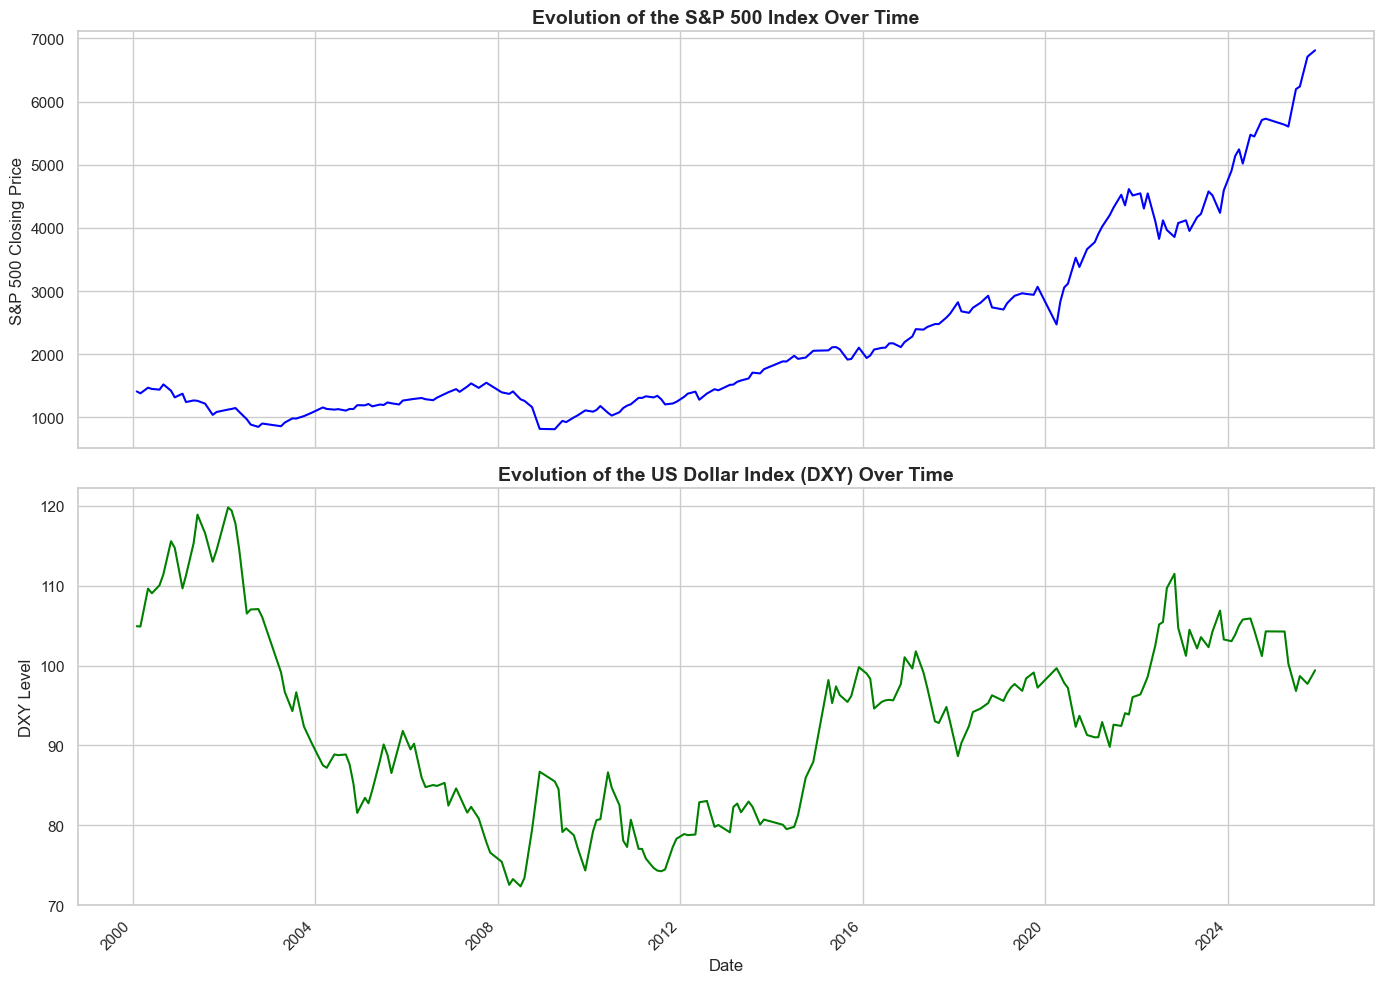

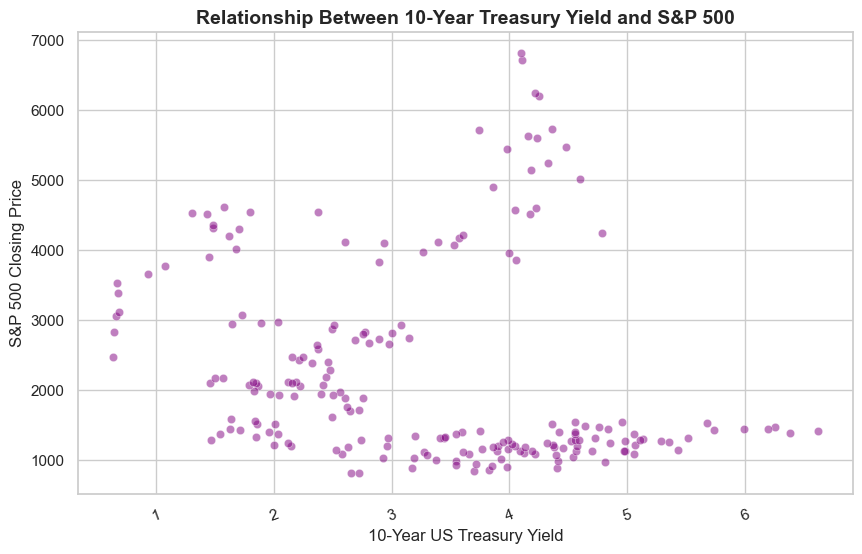

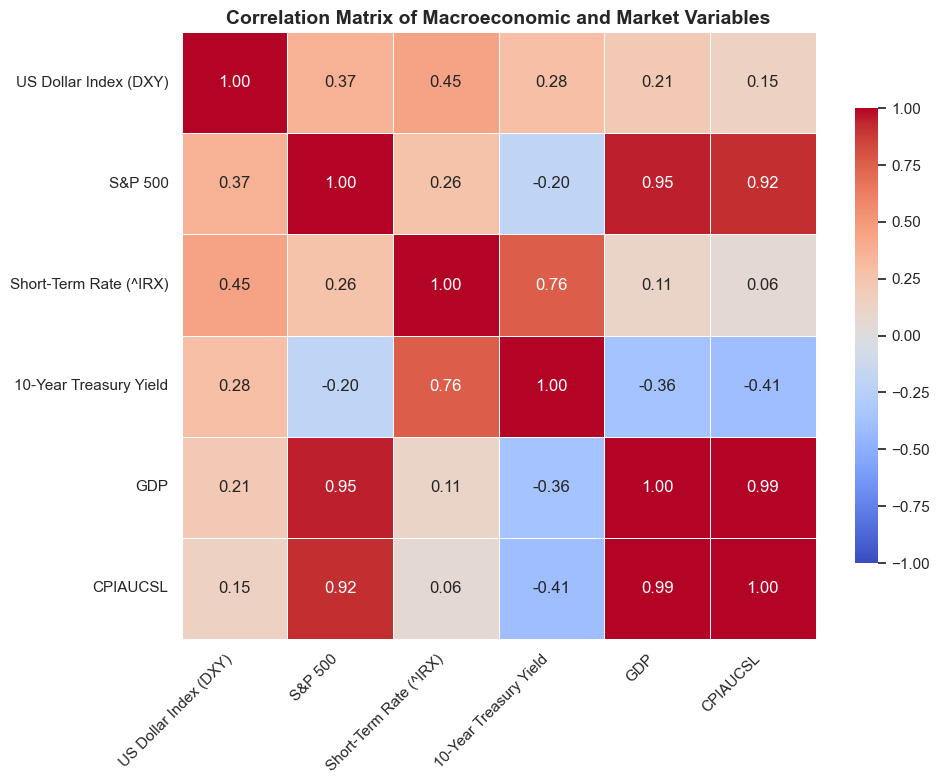

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Ensure seaborn style is applied for professional-looking plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Time-Series Line Charts: S&P 500 and US Dollar Index
# ---------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Subplot 1: S&P 500 Evolution
axes[0].plot(df_merged.index, df_merged['S&P 500'], color='blue', linewidth=1.5)
axes[0].set_title('Evolution of the S&P 500 Index Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('S&P 500 Closing Price', fontsize=12)

# Subplot 2: US Dollar Index Evolution
axes[1].plot(df_merged.index, df_merged['US Dollar Index (DXY)'], color='green', linewidth=1.5)
axes[1].set_title('Evolution of the US Dollar Index (DXY) Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('DXY Level', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)

# Improve date formatting and rotate x-axis labels for readability
# Use a reasonable locator/formatter if many years are present
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Scatterplot: 10-Year Treasury Yield vs S&P 500
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='10-Year Treasury Yield', y='S&P 500', alpha=0.5, color='purple')
plt.title('Relationship Between 10-Year Treasury Yield and S&P 500', fontsize=14, fontweight='bold')
plt.xlabel('10-Year US Treasury Yield', fontsize=12)
plt.ylabel('S&P 500 Closing Price', fontsize=12)
# Rotate x ticks slightly if they are crowded (numeric ticks rarely need rotation)
plt.xticks(rotation=20)
plt.show()

# ---------------------------------------------------------
# 3. Correlation Matrix Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Calculate the Pearson correlation matrix
corr_matrix = df_merged.corr()

# Create the heatmap with seaborn
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
                 cbar_kws={'shrink': 0.75})
# Rotate x tick labels for better readability and align to the right
plt.xticks(rotation=45, ha='right')
# Keep y tick labels horizontal for readability
plt.yticks(rotation=0)
plt.title('Correlation Matrix of Macroeconomic and Market Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
